# Exploring `mujoco/invertedpendulum/expert-v0` with Minari

This notebook loads the Minari expert dataset for the MuJoCo InvertedPendulum environment,
assembles a **100 000 × 5** observation-action matrix, and lays the groundwork for training
a Self-Organizing Map (SOM) on the resulting data.

| Column index | Description |
|---|---|
| 0 | Cart position |
| 1 | Cart velocity |
| 2 | Pole angle |
| 3 | Pole angular velocity |
| 4 | Action (force applied to cart) |

## 1  Imports

In [7]:
import numpy as np
import minari
from minisom import MiniSom
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt

## 2  Load dataset

If the dataset has not been downloaded yet, Minari will fetch it automatically from the remote
registry the first time `load_dataset` is called.

In [3]:
DATASET_ID_EXPERT = "mujoco/invertedpendulum/expert-v0"
DATASET_ID_MEDIUM = "mujoco/invertedpendulum/medium-v0"

# Download if not already cached locally
if DATASET_ID_EXPERT not in minari.list_local_datasets():
    minari.download_dataset(DATASET_ID_EXPERT)

dataset_expert = minari.load_dataset(DATASET_ID_EXPERT)
print(f"Dataset loaded: {DATASET_ID_EXPERT}")
print(f"Total episodes : {dataset_expert.total_episodes}")
print(f"Total steps    : {dataset_expert.total_steps}")

if DATASET_ID_MEDIUM not in minari.list_local_datasets():
    minari.download_dataset(DATASET_ID_MEDIUM)  
dataset_medium = minari.load_dataset(DATASET_ID_MEDIUM)
print(f"Dataset loaded: {DATASET_ID_MEDIUM}")
print(f"Total episodes : {dataset_medium.total_episodes}")
print(f"Total steps    : {dataset_medium.total_steps}")

Dataset loaded: mujoco/invertedpendulum/expert-v0
Total episodes : 100
Total steps    : 100000


/home/mjs161803/git/cart-pole-som/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Fetching 2 files: 100%|██████████| 2/2 [00:01<00:00,  1.83it/s]


Dataset mujoco/invertedpendulum/medium-v0 downloaded to /home/mjs161803/.minari/datasets/mujoco/invertedpendulum/medium-v0
Dataset loaded: mujoco/invertedpendulum/medium-v0
Total episodes : 1040
Total steps    : 99075


## 3  Inspect one episode

Each episode is an `EpisodeData` object with numpy arrays for `observations`, `actions`,
`rewards`, `terminations`, and `truncations`.

> **Note**: Minari stores one *extra* observation per episode (the terminal observation is
> appended), so `observations` has shape `(T+1, obs_dim)` while `actions` has shape
> `(T, act_dim)`.  We use only the first `T` observations to form aligned pairs.

In [5]:
expert_sample_episode = next(iter(dataset_expert.iterate_episodes()))

print("observations shape (Expert) :", expert_sample_episode.observations.shape)
print("   actions shape      :", expert_sample_episode.actions.shape)
print("   rewards shape      :", expert_sample_episode.rewards.shape)

medium_sample_episode = next(iter(dataset_expert.iterate_episodes()))

print("observations shape (Medium):", medium_sample_episode.observations.shape)
print("   actions shape      :", medium_sample_episode.actions.shape)
print("   rewards shape      :", medium_sample_episode.rewards.shape)

observations shape (Expert) : (1001, 4)
   actions shape      : (1000, 1)
   rewards shape      : (1000,)
observations shape (Medium): (1001, 4)
   actions shape      : (1000, 1)
   rewards shape      : (1000,)


## Generate combined numpy matrix for observations

In [6]:
obs_list = []

for episode in dataset_expert.iterate_episodes():
    obs = episode.observations
    obs_list.append(obs[:-1])  # drop terminal observation

for episode in dataset_medium.iterate_episodes():
    obs = episode.observations
    obs_list.append(obs[:-1])

all_observations = np.concatenate(obs_list, axis=0)
print("all_observations shape:", all_observations.shape)

all_observations shape: (199075, 4)


## Statistical Analysis of Observations

Column                    Min        Max       Mean        Std     Median       Skew       Kurt
----------------------------------------------------------------------------------------------------
cart_pos              -1.0298     1.0312    -0.0483     0.2856    -0.0799     0.3098     4.3163
cart_vel              -0.2000     0.2000    -0.0000     0.0411    -0.0006     0.0753     2.4798
pole_angle            -2.0366     1.9588     0.0035     0.4168     0.0057     0.0298     1.1511
pole_ang_vel          -3.3846     3.1573     0.0011     0.7489    -0.0074     0.0601     0.5001


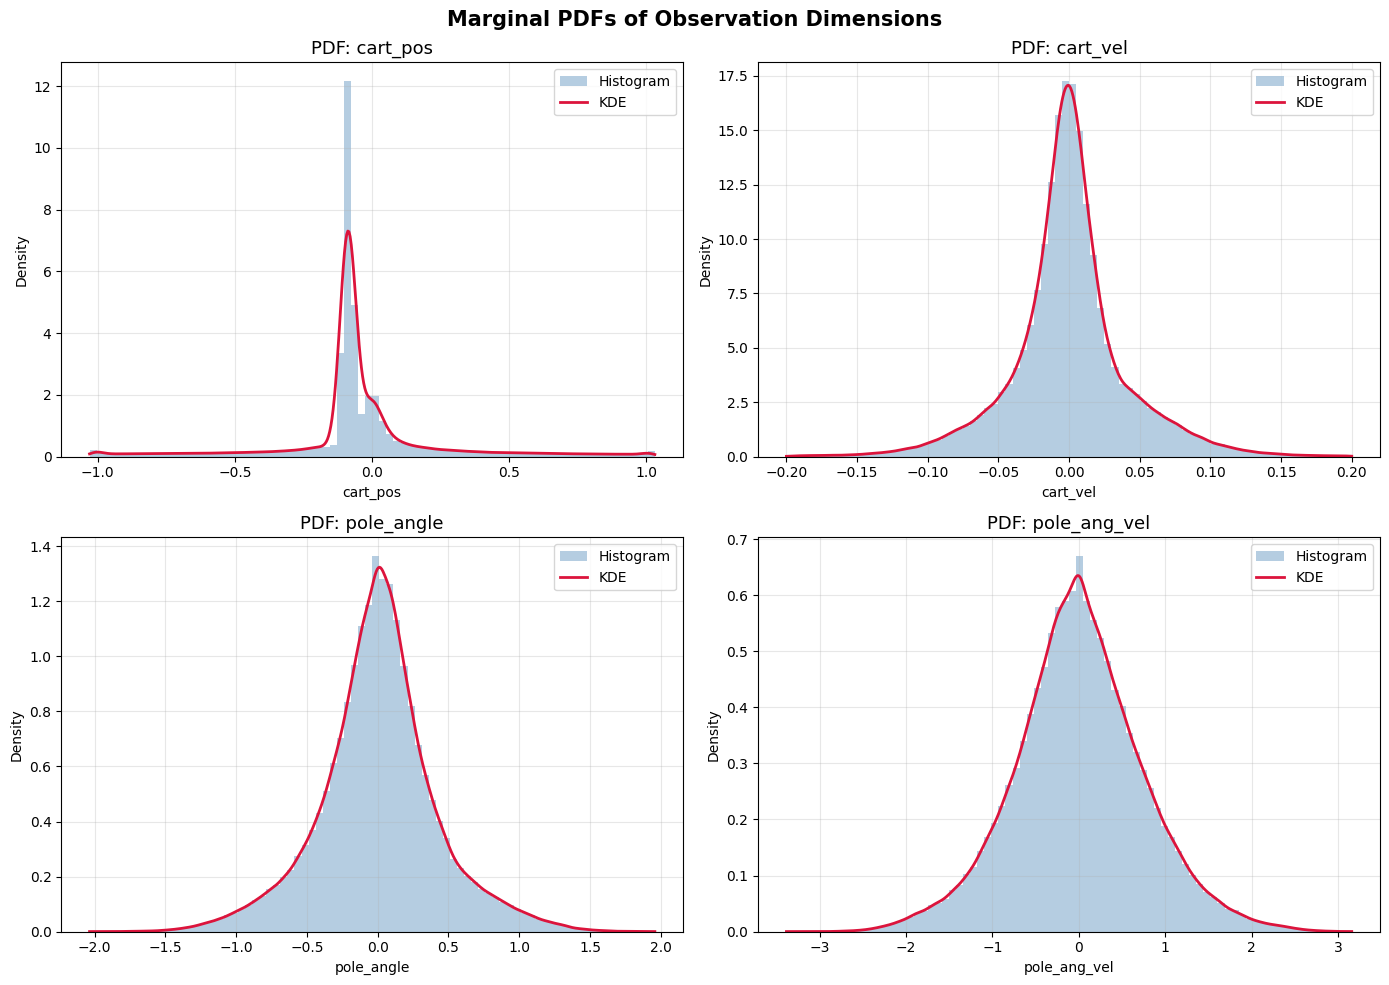

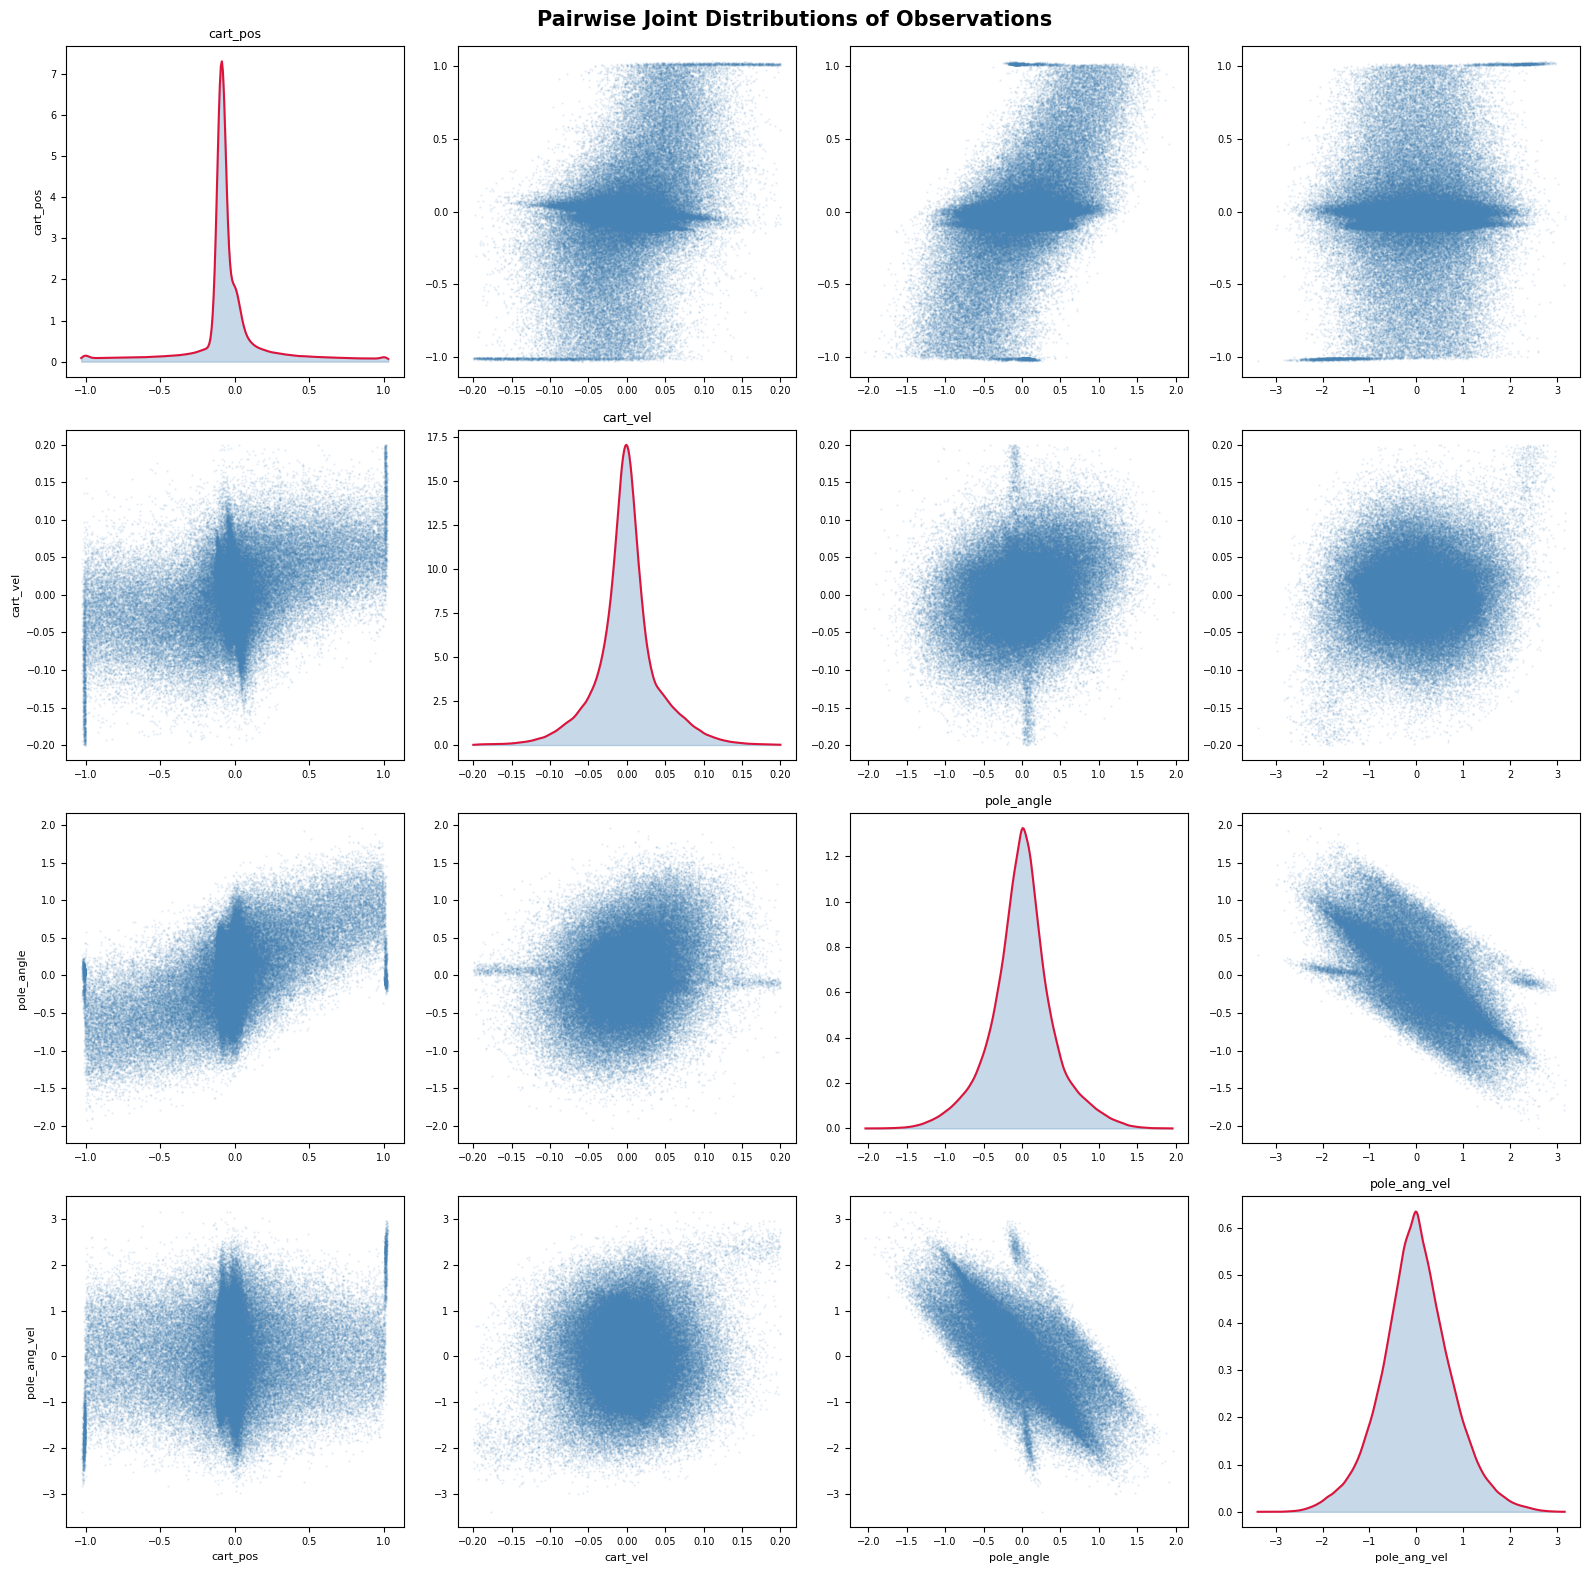

In [8]:
COL_NAMES = ["cart_pos", "cart_vel", "pole_angle", "pole_ang_vel"]

# --- Statistics ---
print(f"{'Column':<18} {'Min':>10} {'Max':>10} {'Mean':>10} {'Std':>10} {'Median':>10} {'Skew':>10} {'Kurt':>10}")
print("-" * 100)
for i, name in enumerate(COL_NAMES):
    col = all_observations[:, i]
    print(f"{name:<18} {col.min():>10.4f} {col.max():>10.4f} {col.mean():>10.4f} "
          f"{col.std():>10.4f} {np.median(col):>10.4f} {skew(col):>10.4f} {kurtosis(col):>10.4f}")

# --- PDF Visualizations ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (name, ax) in enumerate(zip(COL_NAMES, axes)):
    col = all_observations[:, i]
    kde = gaussian_kde(col)
    x = np.linspace(col.min(), col.max(), 500)
    ax.hist(col, bins=80, density=True, alpha=0.4, color="steelblue", label="Histogram")
    ax.plot(x, kde(x), color="crimson", linewidth=2, label="KDE")
    ax.set_title(f"PDF: {name}", fontsize=13)
    ax.set_xlabel(name)
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Marginal PDFs of Observation Dimensions", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

# --- Pairplot-style joint scatter with KDE marginals ---
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
for i in range(4):
    for j in range(4):
        ax = axes[i, j]
        if i == j:
            col = all_observations[:, i]
            kde = gaussian_kde(col)
            x = np.linspace(col.min(), col.max(), 300)
            ax.plot(x, kde(x), color="crimson")
            ax.fill_between(x, kde(x), alpha=0.3, color="steelblue")
            ax.set_title(COL_NAMES[i], fontsize=9)
        else:
            ax.scatter(all_observations[:, j], all_observations[:, i],
                       s=0.5, alpha=0.1, color="steelblue")
        if i == 3:
            ax.set_xlabel(COL_NAMES[j], fontsize=8)
        if j == 0:
            ax.set_ylabel(COL_NAMES[i], fontsize=8)
        ax.tick_params(labelsize=7)

plt.suptitle("Pairwise Joint Distributions of Observations", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

## Statistics of Observations conditioned on Target State (Pole Angle close to 0)

Samples satisfying condition: 13719 / 199075 (6.89%)


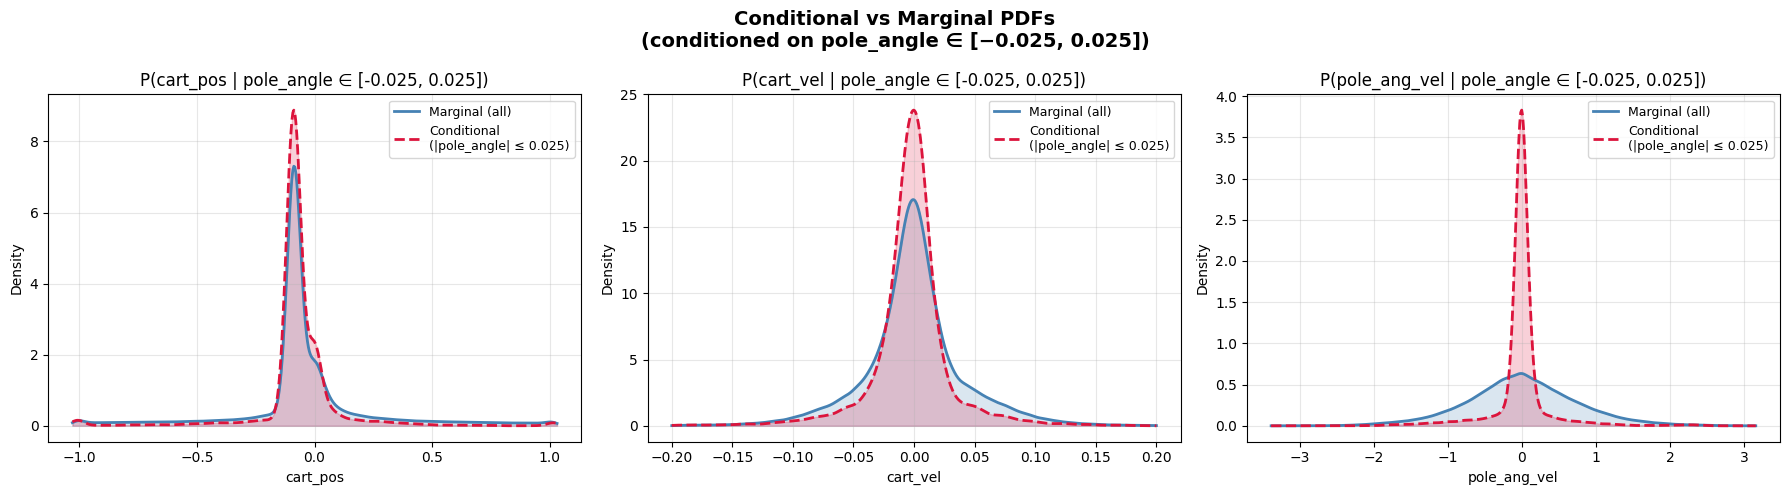

In [11]:
COL_NAMES_COND = ["cart_pos", "cart_vel", "pole_ang_vel"]
COL_INDICES = [0, 1, 3]
TOLERANCE = 0.025

# Condition: pole_angle (col 2) in [-TOLERANCE, +TOLERANCE]
mask = (all_observations[:, 2] >= -TOLERANCE) & (all_observations[:, 2] <= TOLERANCE)
obs_conditioned = all_observations[mask]
obs_unconditioned = all_observations

print(f"Samples satisfying condition: {mask.sum()} / {len(all_observations)} ({100*mask.mean():.2f}%)")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col_idx, name in zip(axes, COL_INDICES, COL_NAMES_COND):
    col_all = obs_unconditioned[:, col_idx]
    col_cond = obs_conditioned[:, col_idx]

    x_min = min(col_all.min(), col_cond.min())
    x_max = max(col_all.max(), col_cond.max())
    x = np.linspace(x_min, x_max, 500)

    kde_all = gaussian_kde(col_all)
    kde_cond = gaussian_kde(col_cond)

    ax.plot(x, kde_all(x), color="steelblue", linewidth=2, label="Marginal (all)")
    ax.fill_between(x, kde_all(x), alpha=0.2, color="steelblue")
    ax.plot(x, kde_cond(x), color="crimson", linewidth=2, linestyle="--",
            label=f"Conditional\n(|pole_angle| ≤ {TOLERANCE:g})")
    ax.fill_between(x, kde_cond(x), alpha=0.2, color="crimson")

    ax.set_title(f"P({name} | pole_angle ∈ [-{TOLERANCE:g}, {TOLERANCE:g}])", fontsize=12)
    ax.set_xlabel(name)
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle(f"Conditional vs Marginal PDFs\n(conditioned on pole_angle ∈ [−{TOLERANCE:g}, {TOLERANCE:g}])",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()